Using Japanese font: Yu Gothic
LFSR設定
段数 m: 5
周期: 31
LFSR1 taps: [2, 4]
LFSR2 taps: [1, 4]
生成系列数: 6
雑音率: 0.1
試行回数: 200

生成されたLFSR系列
S1 seed=[0, 1, 1, 0, 1]: 1011001111100011011101010000100
S2 seed=[1, 1, 1, 1, 1]: 1111100011011101010000100101100
S3 seed=[1, 0, 0, 1, 0]: 0100101100111110001101110101000
S4 seed=[0, 0, 0, 0, 1]: 1000010010110011111000110111010
S5 seed=[0, 1, 1, 0, 0]: 0011011101010000100101100111110
S6 seed=[1, 1, 1, 1, 0]: 0111110001101110101000010010110

Gold系列の例
G1: 0001011110010110100111101000000
G2: 0100000011110101011110000001000
G3: 0110101101000100100010110101100
G4: 0111111010011100011100101111110
G5: 0111010001110000000011100010111

LFSR系列 最大相関行列
[[31 31 31 31 31 31]
 [31 31 31 31 31 31]
 [31 31 31 31 31 31]
 [31 31 31 31 31 31]
 [31 31 31 31 31 31]
 [31 31 31 31 31 31]]

LFSR系列 最大相関シフト行列
[[ 0 25  4  8 19 26]
 [ 6  0 10 14 25  1]
 [27 21  0  4 15 22]
 [23 17 27  0 11 18]
 [12  6 16 20  0  7]
 [ 5 30  9 13 24  0]]

Gold系列 最大相関行列
[[31  7  7  7  7 11  7 11 11  7]
 

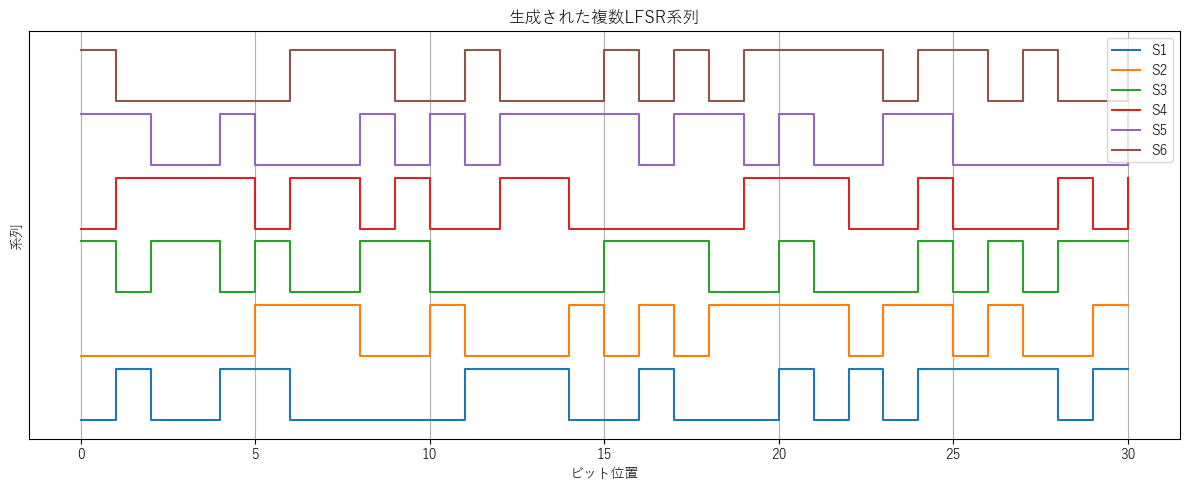

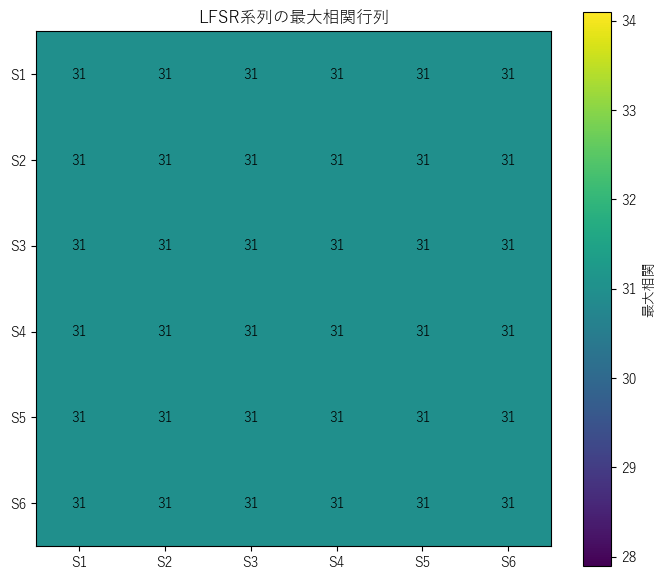

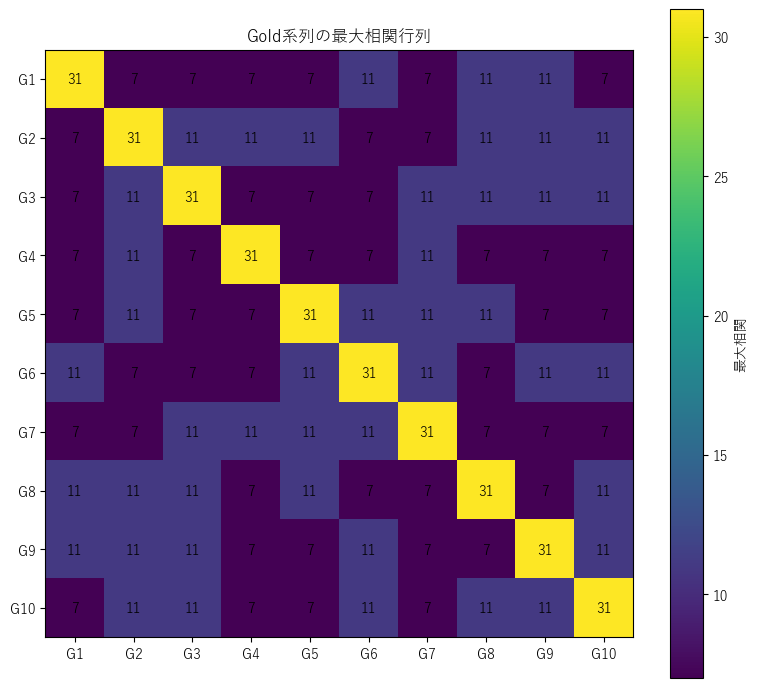

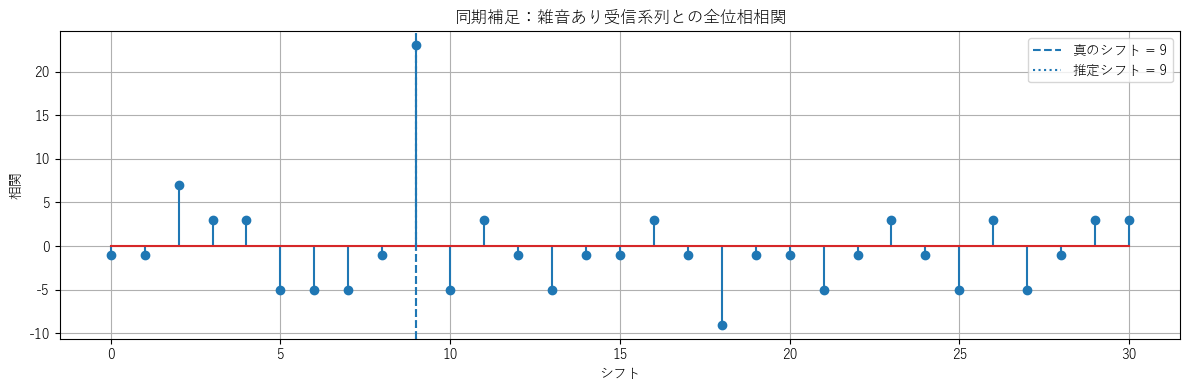

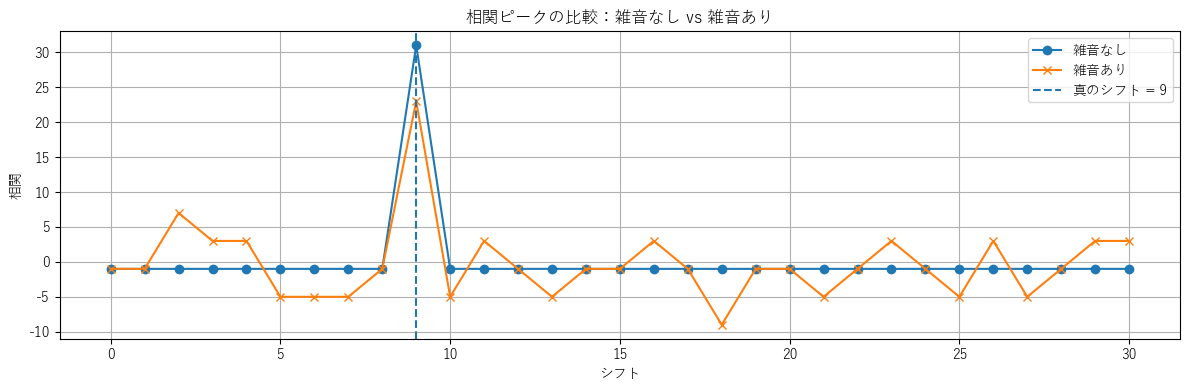

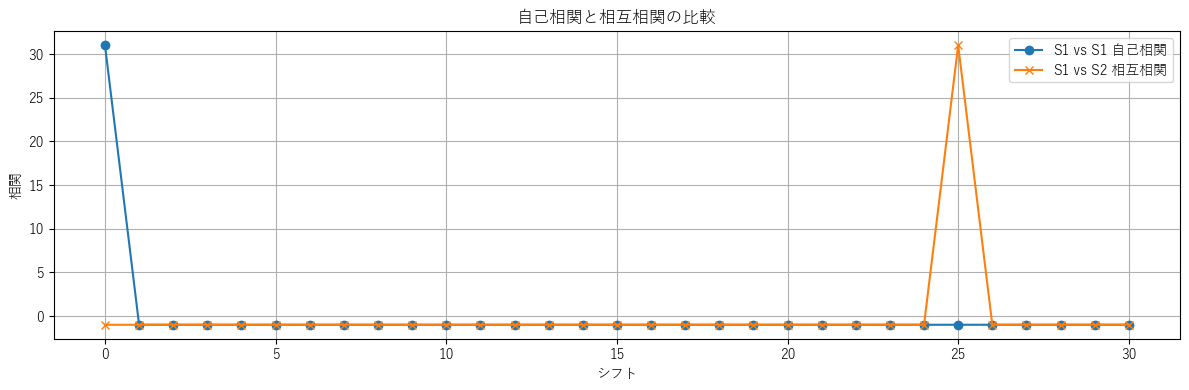

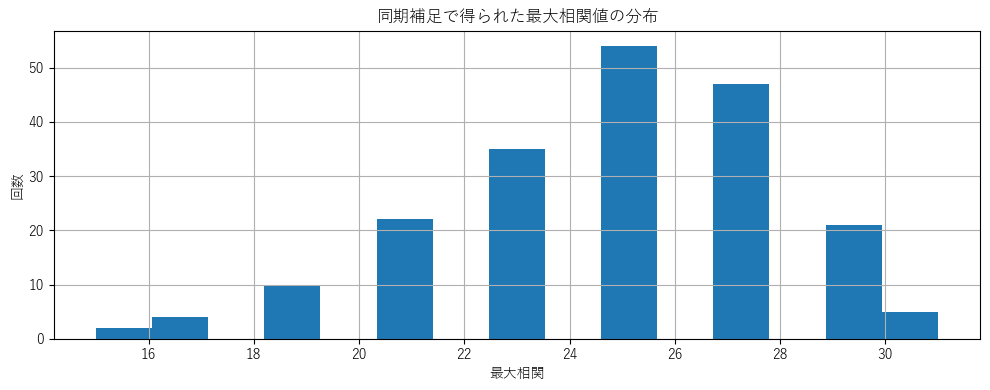

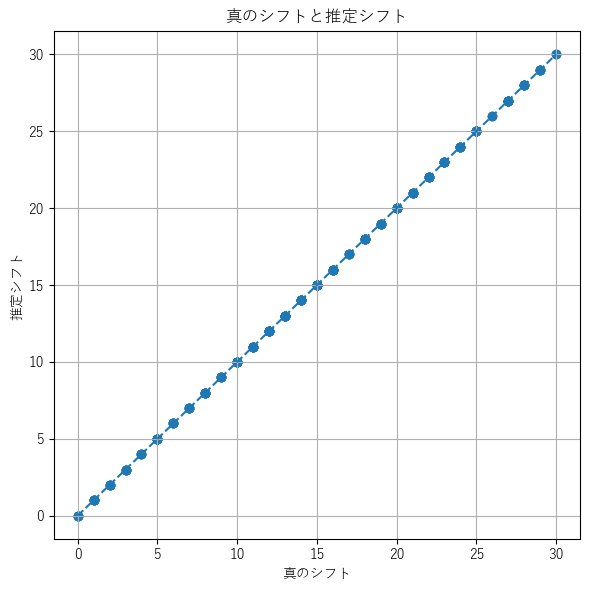


まとめ
1. 同じLFSRで初期値だけ変えた系列は、位相違いになりやすいです。
2. 自己相関は正しい位相で大きなピークを持ちます。
3. 雑音が入るとピークは下がりますが、最大位置が残れば同期できます。
4. Gold系列は複数ユーザー用の系列比較に向いています。
5. 成功率を見ると、雑音率に対する同期補足の強さを評価できます。


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# ============================================================
# Font setup
# ============================================================

def setup_japanese_font():
    candidates = [
        "Yu Gothic",
        "Meiryo",
        "MS Gothic",
        "Yu Mincho",
        "Noto Sans CJK JP",
        "IPAexGothic",
        "TakaoGothic",
    ]

    available = {f.name for f in font_manager.fontManager.ttflist}

    for name in candidates:
        if name in available:
            mpl.rcParams["font.family"] = name
            mpl.rcParams["axes.unicode_minus"] = False
            print("Using Japanese font:", name)
            return True

    mpl.rcParams["font.family"] = "DejaVu Sans"
    mpl.rcParams["axes.unicode_minus"] = False
    print("Japanese font not found. Using English labels.")
    return False


USE_JAPANESE = setup_japanese_font()

def T(jp, en):
    return jp if USE_JAPANESE else en


# ============================================================
# LFSR functions
# ============================================================

def lfsr_sequence(seed, taps, n_bits):
    state = seed[:]
    seq = []

    for _ in range(n_bits):
        out = state[-1]
        seq.append(out)

        feedback = 0
        for t in taps:
            feedback ^= state[t]

        state = [feedback] + state[:-1]

    return np.array(seq, dtype=int)


def bits_to_pm1(bits):
    return np.where(bits == 0, 1, -1)


def cyclic_shift(seq, shift):
    return np.roll(seq, shift)


def cyclic_corr(a, b):
    x = bits_to_pm1(a)
    y = bits_to_pm1(b)

    corr = []
    for shift in range(len(a)):
        corr.append(np.sum(x * np.roll(y, -shift)))

    return np.array(corr)


def max_corr_and_shift(a, b):
    corr = cyclic_corr(a, b)
    shift = int(np.argmax(corr))
    value = int(corr[shift])
    return value, shift, corr


def add_bit_errors(seq, error_rate):
    noisy = seq.copy()
    mask = np.random.rand(len(seq)) < error_rate
    noisy[mask] ^= 1
    return noisy, mask


def random_nonzero_seed(m):
    while True:
        seed = np.random.randint(0, 2, size=m).tolist()
        if sum(seed) > 0:
            return seed


def correlation_matrix(seq_list):
    n = len(seq_list)
    mat = np.zeros((n, n), dtype=int)
    shift_mat = np.zeros((n, n), dtype=int)

    for i in range(n):
        for j in range(n):
            value, shift, _ = max_corr_and_shift(seq_list[i], seq_list[j])
            mat[i, j] = value
            shift_mat[i, j] = shift

    return mat, shift_mat


# ============================================================
# Settings
# ============================================================

np.random.seed(0)

m = 5
period = 2**m - 1

taps_1 = [2, 4]
taps_2 = [1, 4]

num_sequences = 6
error_rate = 0.10
num_trials = 200

print("====================================")
print(T("LFSR設定", "LFSR settings"))
print("====================================")
print(T("段数 m:", "Register length m:"), m)
print(T("周期:", "Period:"), period)
print("LFSR1 taps:", taps_1)
print("LFSR2 taps:", taps_2)
print(T("生成系列数:", "Number of sequences:"), num_sequences)
print(T("雑音率:", "Error rate:"), error_rate)
print(T("試行回数:", "Number of trials:"), num_trials)


# ============================================================
# Generate multiple LFSR sequences
# ============================================================

seeds = [random_nonzero_seed(m) for _ in range(num_sequences)]
sequences = []

for seed in seeds:
    seq = lfsr_sequence(seed, taps_1, period)
    sequences.append(seq)

print("\n====================================")
print(T("生成されたLFSR系列", "Generated LFSR sequences"))
print("====================================")

for i, (seed, seq) in enumerate(zip(seeds, sequences)):
    print(f"S{i+1} seed={seed}: {''.join(map(str, seq))}")


# ============================================================
# Generate Gold sequences
# ============================================================

seed_a = [1, 0, 0, 0, 1]
seed_b = [1, 1, 0, 0, 1]

seq_a = lfsr_sequence(seed_a, taps_1, period)
seq_b = lfsr_sequence(seed_b, taps_2, period)

gold_sequences = []

for shift in range(period):
    gold = seq_a ^ np.roll(seq_b, shift)
    gold_sequences.append(gold)

print("\n====================================")
print(T("Gold系列の例", "Example Gold sequences"))
print("====================================")

for i in range(5):
    print(f"G{i+1}: {''.join(map(str, gold_sequences[i]))}")


# ============================================================
# Correlation matrices
# ============================================================

lfsr_corr_matrix, lfsr_shift_matrix = correlation_matrix(sequences)

gold_num = 10
gold_corr_matrix, gold_shift_matrix = correlation_matrix(gold_sequences[:gold_num])

print("\n====================================")
print(T("LFSR系列 最大相関行列", "LFSR maximum correlation matrix"))
print("====================================")
print(lfsr_corr_matrix)

print("\n====================================")
print(T("LFSR系列 最大相関シフト行列", "LFSR maximum correlation shift matrix"))
print("====================================")
print(lfsr_shift_matrix)

print("\n====================================")
print(T("Gold系列 最大相関行列", "Gold sequence maximum correlation matrix"))
print("====================================")
print(gold_corr_matrix)


# ============================================================
# Synchronization acquisition test
# ============================================================

target_index = 2
true_shift = 9

reference = sequences[target_index]
received_clean = cyclic_shift(reference, true_shift)
received_noisy, error_mask = add_bit_errors(received_clean, error_rate)

corr_clean = cyclic_corr(reference, received_clean)
corr_noisy = cyclic_corr(reference, received_noisy)

estimated_shift_clean = int(np.argmax(corr_clean))
estimated_shift_noisy = int(np.argmax(corr_noisy))

print("\n====================================")
print(T("同期補足テスト", "Synchronization acquisition test"))
print("====================================")
print(T("対象系列:", "Target sequence:"), f"S{target_index+1}")
print(T("本当のシフト:", "True shift:"), true_shift)
print(T("推定シフト 雑音なし:", "Estimated shift clean:"), estimated_shift_clean)
print(T("推定シフト 雑音あり:", "Estimated shift noisy:"), estimated_shift_noisy)
print(T("最大相関 雑音なし:", "Max correlation clean:"), corr_clean[estimated_shift_clean])
print(T("最大相関 雑音あり:", "Max correlation noisy:"), corr_noisy[estimated_shift_noisy])
print(T("ビット誤り数:", "Number of bit errors:"), int(error_mask.sum()))


# ============================================================
# Multiple trials
# ============================================================

success_count = 0
peak_values = []
estimated_shifts = []
true_shifts = []

for _ in range(num_trials):
    true_s = np.random.randint(0, period)
    received = cyclic_shift(reference, true_s)
    noisy, _ = add_bit_errors(received, error_rate)

    corr = cyclic_corr(reference, noisy)
    est_s = int(np.argmax(corr))
    peak = int(corr[est_s])

    if est_s == true_s:
        success_count += 1

    true_shifts.append(true_s)
    estimated_shifts.append(est_s)
    peak_values.append(peak)

success_rate = success_count / num_trials

print("\n====================================")
print(T("同期補足 統計", "Synchronization statistics"))
print("====================================")
print(T("試行回数:", "Trials:"), num_trials)
print(T("成功回数:", "Successes:"), success_count)
print(T("成功率:", "Success rate:"), round(success_rate * 100, 2), "%")
print(T("平均最大相関:", "Mean maximum correlation:"), round(float(np.mean(peak_values)), 2))
print(T("最小最大相関:", "Minimum peak correlation:"), int(np.min(peak_values)))
print(T("最大最大相関:", "Maximum peak correlation:"), int(np.max(peak_values)))


# ============================================================
# Plot 1: Multiple digital waveforms
# ============================================================

plt.figure(figsize=(12, 5))

for i, seq in enumerate(sequences):
    y = bits_to_pm1(seq) + i * 2.5
    plt.step(range(period), y, where="post", label=f"S{i+1}")

plt.title(T("生成された複数LFSR系列", "Generated multiple LFSR sequences"))
plt.xlabel(T("ビット位置", "Bit position"))
plt.ylabel(T("系列", "Sequence"))
plt.yticks([])
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


# ============================================================
# Plot 2: LFSR correlation heatmap
# ============================================================

plt.figure(figsize=(7, 6))
plt.imshow(lfsr_corr_matrix)
plt.colorbar(label=T("最大相関", "Max correlation"))

plt.xticks(range(num_sequences), [f"S{i+1}" for i in range(num_sequences)])
plt.yticks(range(num_sequences), [f"S{i+1}" for i in range(num_sequences)])

for i in range(num_sequences):
    for j in range(num_sequences):
        plt.text(j, i, str(lfsr_corr_matrix[i, j]),
                 ha="center", va="center")

plt.title(T("LFSR系列の最大相関行列", "LFSR maximum correlation matrix"))
plt.tight_layout()
plt.show()


# ============================================================
# Plot 3: Gold sequence correlation heatmap
# ============================================================

plt.figure(figsize=(8, 7))
plt.imshow(gold_corr_matrix)
plt.colorbar(label=T("最大相関", "Max correlation"))

plt.xticks(range(gold_num), [f"G{i+1}" for i in range(gold_num)])
plt.yticks(range(gold_num), [f"G{i+1}" for i in range(gold_num)])

for i in range(gold_num):
    for j in range(gold_num):
        plt.text(j, i, str(gold_corr_matrix[i, j]),
                 ha="center", va="center")

plt.title(T("Gold系列の最大相関行列", "Gold sequence maximum correlation matrix"))
plt.tight_layout()
plt.show()


# ============================================================
# Plot 4: Synchronization correlation graph
# ============================================================

plt.figure(figsize=(12, 4))
plt.stem(range(period), corr_noisy)

plt.axvline(true_shift, linestyle="--", label=T(f"真のシフト = {true_shift}", f"true shift = {true_shift}"))
plt.axvline(estimated_shift_noisy, linestyle=":", label=T(f"推定シフト = {estimated_shift_noisy}", f"estimated shift = {estimated_shift_noisy}"))

plt.title(T("同期補足：雑音あり受信系列との全位相相関",
            "Synchronization acquisition: correlation over all shifts"))
plt.xlabel(T("シフト", "Shift"))
plt.ylabel(T("相関", "Correlation"))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Plot 5: Clean vs noisy correlation
# ============================================================

plt.figure(figsize=(12, 4))

plt.plot(corr_clean, marker="o", label=T("雑音なし", "Clean"))
plt.plot(corr_noisy, marker="x", label=T("雑音あり", "Noisy"))

plt.axvline(true_shift, linestyle="--", label=T(f"真のシフト = {true_shift}", f"true shift = {true_shift}"))

plt.title(T("相関ピークの比較：雑音なし vs 雑音あり",
            "Correlation peak comparison: clean vs noisy"))
plt.xlabel(T("シフト", "Shift"))
plt.ylabel(T("相関", "Correlation"))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Plot 6: Auto-correlation vs cross-correlation
# ============================================================

auto_corr = cyclic_corr(sequences[0], sequences[0])
cross_corr = cyclic_corr(sequences[0], sequences[1])

plt.figure(figsize=(12, 4))
plt.plot(auto_corr, marker="o", label=T("S1 vs S1 自己相関", "S1 vs S1 auto-correlation"))
plt.plot(cross_corr, marker="x", label=T("S1 vs S2 相互相関", "S1 vs S2 cross-correlation"))

plt.title(T("自己相関と相互相関の比較",
            "Auto-correlation vs cross-correlation"))
plt.xlabel(T("シフト", "Shift"))
plt.ylabel(T("相関", "Correlation"))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Plot 7: Peak correlation distribution
# ============================================================

plt.figure(figsize=(10, 4))
plt.hist(peak_values, bins=15)

plt.title(T("同期補足で得られた最大相関値の分布",
            "Distribution of maximum correlation values"))
plt.xlabel(T("最大相関", "Maximum correlation"))
plt.ylabel(T("回数", "Count"))
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# Plot 8: True shift vs estimated shift
# ============================================================

plt.figure(figsize=(6, 6))
plt.scatter(true_shifts, estimated_shifts)

plt.plot([0, period - 1], [0, period - 1], linestyle="--")

plt.title(T("真のシフトと推定シフト",
            "True shift vs estimated shift"))
plt.xlabel(T("真のシフト", "True shift"))
plt.ylabel(T("推定シフト", "Estimated shift"))
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# Summary
# ============================================================

print("\n====================================")
print(T("まとめ", "Summary"))
print("====================================")
print(T("1. 同じLFSRで初期値だけ変えた系列は、位相違いになりやすいです。",
        "1. Sequences generated by the same LFSR with different seeds are often phase-shifted versions."))
print(T("2. 自己相関は正しい位相で大きなピークを持ちます。",
        "2. Auto-correlation has a large peak at the correct phase."))
print(T("3. 雑音が入るとピークは下がりますが、最大位置が残れば同期できます。",
        "3. Noise lowers the peak, but synchronization works if the peak remains detectable."))
print(T("4. Gold系列は複数ユーザー用の系列比較に向いています。",
        "4. Gold sequences are useful for comparing multiple-user spreading codes."))
print(T("5. 成功率を見ると、雑音率に対する同期補足の強さを評価できます。",
        "5. The success rate shows robustness against bit errors."))